In [1]:
!ls /kaggle/input/new-plant-diseases-dataset/New\ Plant\ Diseases\ Dataset\(Augmented\)/'New Plant Diseases Dataset(Augmented)'

ls: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented): No such file or directory


In [2]:
import os
import pickle
import numpy as np
import cv2
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Activation, Flatten, Dropout, Dense
from tensorflow.keras import backend as K
from tensorflow.keras.losses import CategoricalCrossentropy, SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
img_size=(256,256)
n_img=100
root_dir="/Users/shashwatraj/Garud-Plant-Disease-Detection/plantsDataset/plants_dataset"
train_dir=os.path.join(root_dir,"train")
val_dir=os.path.join(root_dir,"valid")

In [4]:
def convert(img_dir):
    try:
        img=cv2.imread(img_dir)
        if img is not None:
            img=cv2.resize(img,img_size)
            return img_to_array(img)
        else:
            return np.array([])
    except:
        print("Error!")
        return None

In [5]:
img_list_train=[]
label_list_train=[]
try:
    print("Loading images...")
    diseases_folders_list=os.listdir(train_dir)
    for diseases_folder in diseases_folders_list:
        print(f"Processing {diseases_folder}...")
        diseases_images_list=os.listdir(f"{train_dir}/{diseases_folder}/")
        for image in tqdm(diseases_images_list):
            image_directory=f"{train_dir}/{diseases_folder}/{image}"
            if image_directory.endswith(".jpg")==True or image_directory.endswith(".JPG")==True:
                img_list_train.append(image_directory)
                label_list_train.append(diseases_folder)
    print("Images processed!")
except Exception as e:
    print(f"Error:{e}")
print("Number of images processed:",len(img_list_train))

Loading images...
Processing Strawberry___healthy...


100%|██████████| 1824/1824 [00:00<00:00, 2779945.67it/s]


Processing Grape___Black_rot...


100%|██████████| 1888/1888 [00:00<00:00, 3295399.90it/s]


Processing Potato___Early_blight...


...

Processing Potato___healthy...


100%|██████████| 1824/1824 [00:00<00:00, 3293332.11it/s]


Processing Soybean___healthy...


100%|██████████| 2022/2022 [00:00<00:00, 2717360.68it/s]

Images processed!
Number of images processed: 70295


In [6]:
img_list_valid=[]
label_list_valid=[]
try:
    print("Loading images...")
    diseases_folders_list=os.listdir(val_dir)
    for diseases_folder in diseases_folders_list:
        print(f"Processing {diseases_folder}...")
        diseases_images_list=os.listdir(f"{val_dir}/{diseases_folder}/")
        for image in tqdm(diseases_images_list):
            image_directory=f"{val_dir}/{diseases_folder}/{image}"
            if image_directory.endswith(".jpg")==True or image_directory.endswith(".JPG")==True:
                img_list_valid.append(image_directory)
                label_list_valid.append(diseases_folder)
    print("Images processed!")
except Exception as e:
    print(f"Error:{e}")
print("Number of images processed:",len(img_list_valid))

Loading images...
Processing Strawberry___healthy...


100%|██████████| 456/456 [00:00<00:00, 3125167.69it/s]


Processing Grape___Black_rot...


100%|██████████| 472/472 [00:00<00:00, 3083662.75it/s]


Processing Potato___Early_blight...


...

Processing Potato___healthy...


100%|██████████| 456/456 [00:00<00:00, 1299322.43it/s]


Processing Soybean___healthy...


100%|██████████| 505/505 [00:00<00:00, 3664573.56it/s]

Images processed!
Number of images processed: 17572


In [7]:
import pandas as pd
df_train = pd.DataFrame({'image': img_list_train, 'label': label_list_train})
df_valid = pd.DataFrame({'image': img_list_valid, 'label': label_list_valid})
print("Training DataFrame:")
print(df_train.shape)
print("Validation DataFrame:")  
print(df_valid.shape)

Training DataFrame:
(70295, 2)
Validation DataFrame:
(17572, 2)


In [8]:
pickle.dump(df_train, open("train_df.pkl", "wb"))
pickle.dump(df_valid, open("valid_df.pkl", "wb"))
print(df_train.head(5))
print(df_valid.head(5)) 

                                               image                 label
0  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
1  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
2  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
3  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
4  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
                                               image                 label
0  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
1  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
2  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
3  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy
4  /Users/shashwatraj/Garud-Plant-Disease-Detecti...  Strawberry___healthy


In [9]:
data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = data.flow_from_dataframe(
    dataframe=df_train,
    x_col='image',
    y_col='label',
    target_size=(img_size[0],img_size[1]),
    batch_size=n_img,
    class_mode='sparse',
    shuffle=True
)

val_data = data.flow_from_dataframe(
    dataframe=df_valid,
    x_col='image',
    y_col='label',
    target_size=(img_size[0],img_size[1]),
    batch_size=n_img,
    class_mode='sparse',
    shuffle=True
    
)
print("Training data shape:", train_data[0][0].shape)
print("Validation data shape:", val_data[0][0].shape)

Found 70295 validated image filenames belonging to 38 classes.
Found 17572 validated image filenames belonging to 38 classes.
Training data shape: (100, 256, 256, 3)
Validation data shape: (100, 256, 256, 3)


In [10]:
EPOCHS=10
LR=1e-3
bs=32
height=img_size[1]
width=img_size[0]
depth=3

In [18]:
model=Sequential()
inputShape=(height,width,depth)
model.add(Conv2D(32,kernel_size=(3,3),padding="same",input_shape=inputShape))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3)))
model.add(Dropout(0.25))
model.add(Conv2D(64,kernel_size=(3,3),padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(128,kernel_size=(3,3),padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(256,kernel_size=(3,3),padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))) 
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(38, kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(Activation('linear'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 85, 85, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 85, 85, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 85, 85, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 85, 85, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 42, 42, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 42, 42, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 42, 42, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 21, 21, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 256)            │             

 Total params: 6,954,982 (26.53 MB)

 Trainable params: 6,953,510 (26.53 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [19]:
o=Adamax(learning_rate=LR)
model.compile(loss=SparseCategoricalCrossentropy(from_logits=True),optimizer=o,metrics=["accuracy"])
print("Training model...")
history=model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=EPOCHS,
    validation_data=val_data,
    validation_steps=len(val_data),
    verbose=1,
    shuffle=True
) 

Training model...
Epoch 1/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 8400s 12s/step - accuracy: 0.5117 - loss: 5.6083 - val_accuracy: 0.2272 - val_loss: 6.0789
Epoch 2/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 5173s 7s/step - accuracy: 0.8226 - loss: 1.6543 - val_accuracy: 0.4723 - val_loss: 3.1260
Epoch 3/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 14468s 21s/step - accuracy: 0.8865 - loss: 1.1261 - val_accuracy: 0.7354 - val_loss: 1.4988
Epoch 4/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 12670s 18s/step - accuracy: 0.9141 - loss: 0.9006 - val_accuracy: 0.8107 - val_loss: 1.1414
Epoch 5/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 10015s 14s/step - accuracy: 0.9271 - loss: 0.7821 - val_accuracy: 0.7546 - val_loss: 1.2897
Epoch 6/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 5864s 8s/step - accuracy: 0.9407 - loss: 0.6841 - val_accuracy: 0.7770 - val_loss: 1.1556
Epoch 7/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 5896s 8s/step - accuracy: 0.9472 - loss: 0.6205 - val_accuracy: 0.8062 - val_loss: 1.0420
Epoch 8/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 19995s 28s/step - accurac

In [24]:
model.save("plant_disease_model.keras")
print("Model saved as 'plant_disease_model.keras'")

Model saved as 'plant_disease_model.keras'


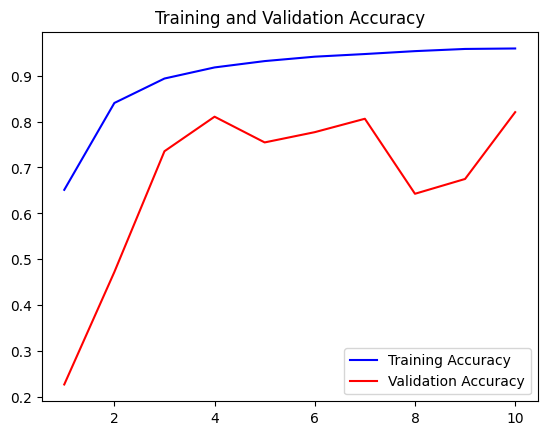

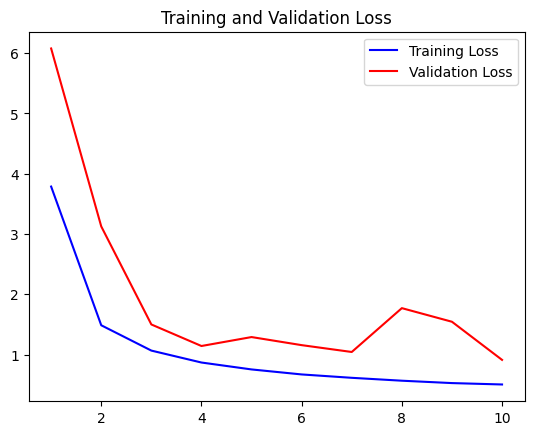

In [21]:
accuracy=history.history["accuracy"]
validation_accuracy=history.history["val_accuracy"]
loss=history.history["loss"]
validation_loss=history.history["val_loss"]
epochs=range(1,len(accuracy)+1)
plt.plot(epochs,accuracy,"b",label="Training Accuracy")
plt.plot(epochs,validation_accuracy,"r",label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()
plt.plot(epochs,loss,"b",label="Training Loss")
plt.plot(epochs,validation_loss,"r",label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [22]:
test_dir="/Users/shashwatraj/Garud-Plant-Disease-Detection/test"
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_size[0],img_size[1]),
    batch_size=n_img,
    shuffle=False
    
)

Found 33 files belonging to 1 classes.


In [23]:
labels_pred = model.predict(test_data)
#test_data_onehot = test_data.map(lambda x, y: (x, tf.one_hot(y, depth=38)))
print(model.evaluate(test_data)[1]*100)
print(model.evaluate(val_data)[1]*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.0000e+00 - loss: 1300.7825
0.0
176/176 ━━━━━━━━━━━━━━━━━━━━ 100s 569ms/step - accuracy: 0.8215 - loss: 0.9075
81.77782893180847


In [91]:
def predict(img_path):
    img_arr=convert(img_path)
    np_img=np.array(img_arr,dtype=np.float16)/255.0
    np_img=np.expand_dims(np_img,0)
    fig,ax=plt.subplots(1,1)
    result=model.predict_classes(np_img)
    plt.imshow(plt.imread(img_path))
    plt.show()

In [92]:
import glob
images=glob.glob(".png") #add image here.
for img in images:
    predict(img)